In [1]:
# Jupyter Notebook for the modelling phase of the project. This notebook contains the code for training 
# and evaluating the machine learning models used in the project.
import sys
from pathlib import Path

project_root = Path.cwd().parent
print("Project root should be:", project_root)

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

print("sys.path now contains project root:", str(project_root) in sys.path)

Project root should be: /Users/rahimabbas/Projects/d2
sys.path now contains project root: True


In [2]:
# Load required imports
import pandas as pd
from src.data_ingestion import load_application_train, load_bureau, load_previous_application
from src.feature_engineering import engineer_features_pipeline

pd.set_option('display.max_columns', None)

In [3]:
# Loading and engineering the data
df_raw = load_application_train()
bureau_raw = load_bureau()
prev_app_raw = load_previous_application()

# Performing the feature engineering pipeline function
df = engineer_features_pipeline(df_raw , bureau_raw , prev_app_raw)
print(df.shape)
print(df.isnull().sum().sum())

Loaded application_train: 307511 rows, 122 columns
Loaded bureau: 1716428 rows, 17 columns
Loaded previous_application: 1670214 rows, 37 columns
(307511, 137)
0


In [4]:
# Separating X (everything else in model) and Y (preditcting) variables
y = df['TARGET']
X = df.drop(columns=['TARGET' , 'SK_ID_CURR'])
print(X.shape)
print(y.shape)
print(y.value_counts(normalize=True))

(307511, 135)
(307511,)
TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64


In [5]:
# Checking the categorical features
categorical_cols = X.select_dtypes(include=['object' , 'str']).columns
print(len(categorical_cols))
print(categorical_cols.tolist())

16
['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'FONDKAPREMONT_MODE', 'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE']


In [6]:
# Checking the unique values in the categorical features before hot encoding
for col in categorical_cols:
    print(f"Column: {col} | Unique Values: {X[col].nunique()} | Unique Categories: {X[col].unique()}")

Column: NAME_CONTRACT_TYPE | Unique Values: 2 | Unique Categories: <StringArray>
['Cash loans', 'Revolving loans']
Length: 2, dtype: str
Column: CODE_GENDER | Unique Values: 3 | Unique Categories: <StringArray>
['M', 'F', 'XNA']
Length: 3, dtype: str
Column: FLAG_OWN_CAR | Unique Values: 2 | Unique Categories: <StringArray>
['N', 'Y']
Length: 2, dtype: str
Column: FLAG_OWN_REALTY | Unique Values: 2 | Unique Categories: <StringArray>
['Y', 'N']
Length: 2, dtype: str
Column: NAME_TYPE_SUITE | Unique Values: 8 | Unique Categories: <StringArray>
[  'Unaccompanied',          'Family', 'Spouse, partner',        'Children',
         'Other_A',         'Unknown',         'Other_B', 'Group of people']
Length: 8, dtype: str
Column: NAME_INCOME_TYPE | Unique Values: 8 | Unique Categories: <StringArray>
[             'Working',        'State servant', 'Commercial associate',
            'Pensioner',           'Unemployed',              'Student',
          'Businessman',      'Maternity leave']
Le

In [10]:
# Performing one-hot encoding on the categorical features
from src.feature_engineering import encode_categorical_features
X_encoded = encode_categorical_features(X)
print(X_encoded.shape)
print(X_encoded.select_dtypes(include=['object', 'str']).columns.tolist())

(307511, 249)
[]


In [14]:
# Splitting the data in test and train sets
from sklearn.model_selection import train_test_split
X_train , X_test , y_train , y_test = train_test_split(
    X_encoded , y ,
    test_size = 0.2,
    random_state = 42,
    stratify = y
)
print(X_train.shape , X_test.shape)
print(y_train.value_counts(normalize = True))
print(y_test.value_counts(normalize = True))

(246008, 249) (61503, 249)
TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64
TARGET
0    0.919272
1    0.080728
Name: proportion, dtype: float64


In [15]:
'''
    Adding the standard scaler because logistic regression is sensitive to the scale of the features.
    This will help to improve the performance of the model.
'''
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print(X_train_scaled.shape , X_test_scaled.shape)


(246008, 249) (61503, 249)


In [16]:
# Training the logistic regression model
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(
    max_iter = 1000,
    random_state = 42,
    class_weight = 'balanced'
)
model.fit(X_train_scaled , y_train)
print('Logistic Regression model trained successfully!')

Logistic Regression model trained successfully!


In [17]:
# Evaluating the model on the test set using proper metrics
from sklearn.metrics import (
    accuracy_score , precision_score , recall_score , f1_score , 
    roc_auc_score , confusion_matrix , classification_report
)

y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.6937872949287026
Precision: 0.16411548149583413
Recall: 0.6823766364551863
F1 Score: 0.2645944785036511
ROC-AUC: 0.7542176750572485

Confusion Matrix:
[[39282 17256]
 [ 1577  3388]]

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.69      0.81     56538
           1       0.16      0.68      0.26      4965

    accuracy                           0.69     61503
   macro avg       0.56      0.69      0.54     61503
weighted avg       0.90      0.69      0.76     61503



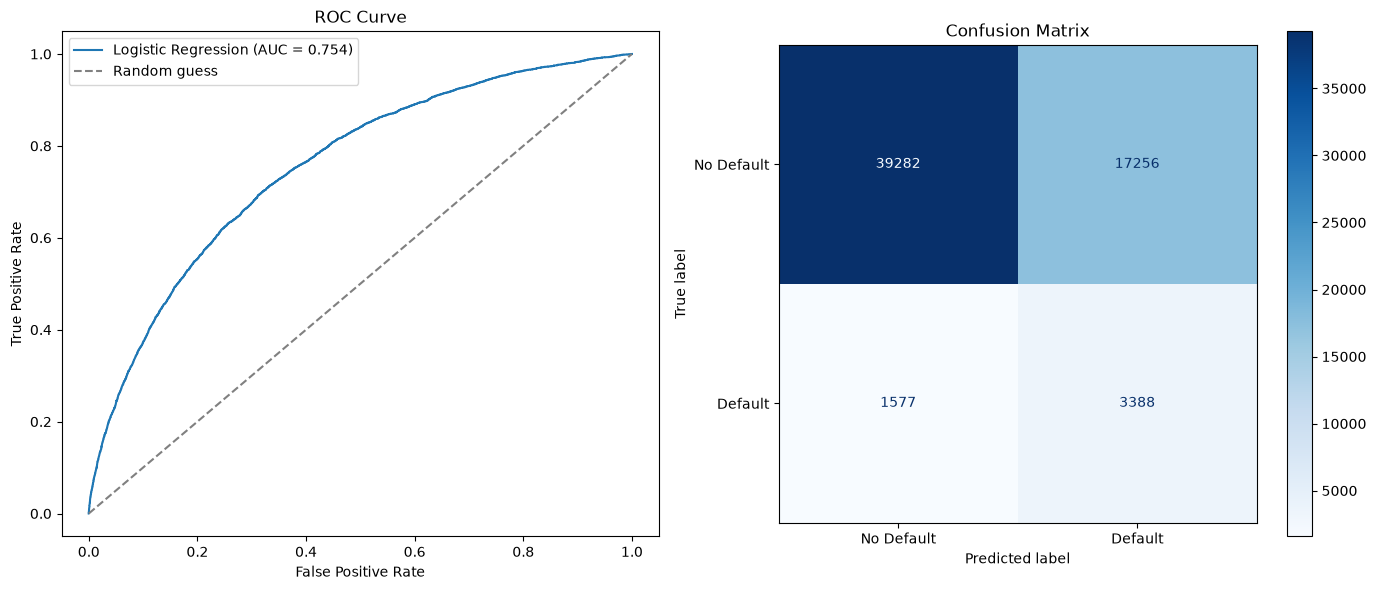

In [19]:
# Visualizing the ROC curve & Confusion Matrix
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
axes[0].plot(fpr, tpr, label=f'Logistic Regression (AUC = {roc_auc_score(y_test, y_pred_proba):.3f})')
axes[0].plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random guess')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve')
axes[0].legend()

# Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['No Default', 'Default'],
    ax=axes[1],
    cmap='Blues'
)
axes[1].set_title('Confusion Matrix')

plt.tight_layout()
plt.savefig('../models/baseline_evaluation.png', dpi=150)
plt.show()